In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
%matplotlib inline



In [12]:
alk = pd.read_csv('ALK.csv')
payx = pd.read_csv('PAYX.csv')
schw = pd.read_csv('SCHW.csv')
see = pd.read_csv('SEE.csv')
ste = pd.read_csv('STE.csv')

In [13]:
alk['Date'] = pd.to_datetime(alk['Date'])
alk = alk.set_index('Date')
 
payx['Date'] = pd.to_datetime(payx['Date'])
payx = payx.set_index('Date')
 
schw['Date'] = pd.to_datetime(schw['Date'])
schw = schw.set_index('Date')
 
see['Date'] = pd.to_datetime(see['Date'])
see = see.set_index('Date')
 
ste['Date'] = pd.to_datetime(ste['Date'])
ste = ste.set_index('Date')

In [14]:
#create a dictionarie 
companies = {'ALK': alk, 'PAYX': payx, 'SCHW': schw, 'SEE': see, 'STE': ste}


In [15]:
#Task 1
print("TASK 1")
for name, df in companies.items():
    diff = df['High'] - df['Low']
    count_zero = (diff == 0).sum()
    print(f"{name}: days with High == Low: {count_zero}")
#The price remainede the same in that days

TASK 1
ALK: days with High == Low: 0
PAYX: days with High == Low: 0
SCHW: days with High == Low: 0
SEE: days with High == Low: 0
STE: days with High == Low: 0


In [16]:
#Task 2 
print("TASK 2")
# highest price can be in High column, lowest price can be in Low column
for name, df in companies.items():
    highest = df['High'].max()
    lowest = df['Low'].min()
    print(f"{name}: highest price = {highest}, lowest price = {lowest}")
    

TASK 2
ALK: highest price = 74.25, lowest price = 30.75
PAYX: highest price = 146.128, lowest price = 74.076
SCHW: highest price = 91.37, lowest price = 43.335
SEE: highest price = 65.742, lowest price = 27.18
STE: highest price = 248.489, lowest price = 154.571


In [17]:
#Task 3 
for name, df in companies.items():
    log_ret = np.log(df['Close'] / df['Close'].shift(1))
    log_ret = log_ret.dropna()
    print(f"{name}")
    print(f" min = {log_ret.min():.6f}")
    print(f" max = {log_ret.max():.6f}")
    print(f" mean = {log_ret.mean():.6f}")
    print(f" std = {log_ret.std():.6f}")
    print(f" skew = {log_ret.skew():.6f}")
    
                     

ALK
 min = -0.153396
 max = 0.123674
 mean = 0.000275
 std = 0.023375
 skew = -0.214845
PAYX
 min = -0.072653
 max = 0.062693
 mean = 0.000546
 std = 0.014105
 skew = -0.233766
SCHW
 min = -0.136612
 max = 0.118394
 mean = 0.000389
 std = 0.021626
 skew = -0.486605
SEE
 min = -0.114752
 max = 0.090873
 mean = -0.000220
 std = 0.019538
 skew = -0.405904
STE
 min = -0.115321
 max = 0.093729
 mean = 0.000120
 std = 0.016494
 skew = -0.586439


In [18]:
#Save the data
alk['log_ret'] = np.log(alk['Close'] / alk['Close'].shift(1))
payx['log_ret'] = np.log(payx['Close'] / payx['Close'].shift(1))
schw['log_ret'] = np.log(schw['Close'] / schw['Close'].shift(1))
see['log_ret'] = np.log(see['Close'] / see['Close'].shift(1))
ste['log_ret'] = np.log(ste['Close'] / ste['Close'].shift(1))


In [32]:
#Task 4
for name, df in companies.items():
    ret = df['log_ret'].dropna()
#Second highest value
first_max_idx = ret.idxmax()
ret_no_max = ret.drop(index=first_max_idx)
second_gain_date = ret_no_max.idxmax()
second_gain_val = ret_no_max[second_gain_date]
#Second lowest value
first_min_idx = ret.idxmin()
ret_no_min = ret.drop(index=first_min_idx)
second_loss_date = ret_no_min.idxmin()
second_loss_val = ret_no_min[second_loss_date]
print(f"  2nd highest gain : {second_gain_date.date()} ({second_gain_val:.6f})")
print(f"  2nd highest loss : {second_loss_date.date()} ({second_loss_val:.6f})")


  2nd highest gain : 2024-05-09 (0.072951)
  2nd highest loss : 2022-08-03 (-0.100402)


In [34]:
#Task 5
for name, df in companies.items():
#Resample by week and sum volumes
    weekly_vol = df['Volume'].resample('W').sum()
    median_weekly_vol = weekly_vol.median()
print(f"{name}: median weekly volume = {median_weekly_vol:.0f}")
    

STE: median weekly volume = 2313700


In [35]:
#Task 6
for name, df in companies.items():
    total = df['log_ret'].sum()
    print(f"{name}: total log return = {total:.6f}")
    
total_returns = {}
for name, df in companies.items():
    total_returns[name] = df['log_ret'].sum()
 
min_company = min(total_returns, key=total_returns.get)
print(f"Lowest total log return: {min_company} ({total_returns[min_company]:.6f})")

ALK: total log return = 0.275679
PAYX: total log return = 0.547760
SCHW: total log return = 0.390437
SEE: total log return = -0.220376
STE: total log return = 0.120785
Lowest total log return: SEE (-0.220376)


In [37]:
#Task 7
for name, df in companies.items():
    df['volume_class'] = pd.qcut(df['Volume'],q=3,labels=['Low', 'Medium', 'High'])
    print(f"{name} volume_class counts:")
    print(df['volume_class'].value_counts())

ALK volume_class counts:
volume_class
Low       335
High      335
Medium    334
Name: count, dtype: int64
PAYX volume_class counts:
volume_class
Low       335
High      335
Medium    334
Name: count, dtype: int64
SCHW volume_class counts:
volume_class
Low       335
High      335
Medium    334
Name: count, dtype: int64
SEE volume_class counts:
volume_class
Low       335
High      335
Medium    334
Name: count, dtype: int64
STE volume_class counts:
volume_class
Low       335
High      335
Medium    334
Name: count, dtype: int64


In [ ]:
#Task 8


In [43]:
#Problem 2
df = pd.read_csv('companies_no_subindustry.csv')

In [44]:
#Task 1
print("Missing included:", df['included'].isna().sum())


Missing included: 45


In [45]:
#Task 2
df = df.dropna(subset=['included'])
df['included'] = pd.to_datetime(df['included'], dayfirst=True, errors='coerce')
print("Oldest:", df.loc[df['included'].idxmin(), ['Security', 'included']].values)
print("Youngest:", df.loc[df['included'].idxmax(), ['Security', 'included']].values)
 
df['Founded'] = pd.to_datetime(df['Founded'].astype(str).str[:4], format='%Y', errors='coerce')
df['age_years'] = (pd.Timestamp.today() - df['Founded']).dt.days / 365.25
print("Median age (years):", df['age_years'].median().round(1))

Oldest: ['Altria' Timestamp('1957-03-04 00:00:00')]
Youngest: ['Arch Capital Group' Timestamp('2022-11-01 00:00:00')]


AttributeError: 'float' object has no attribute 'round'

In [ ]:
#Task 3
sector_counts = df['GICS_Sector'].value_counts()
sector_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), title='Companies by Sector')
plt.ylabel('')
plt.show()

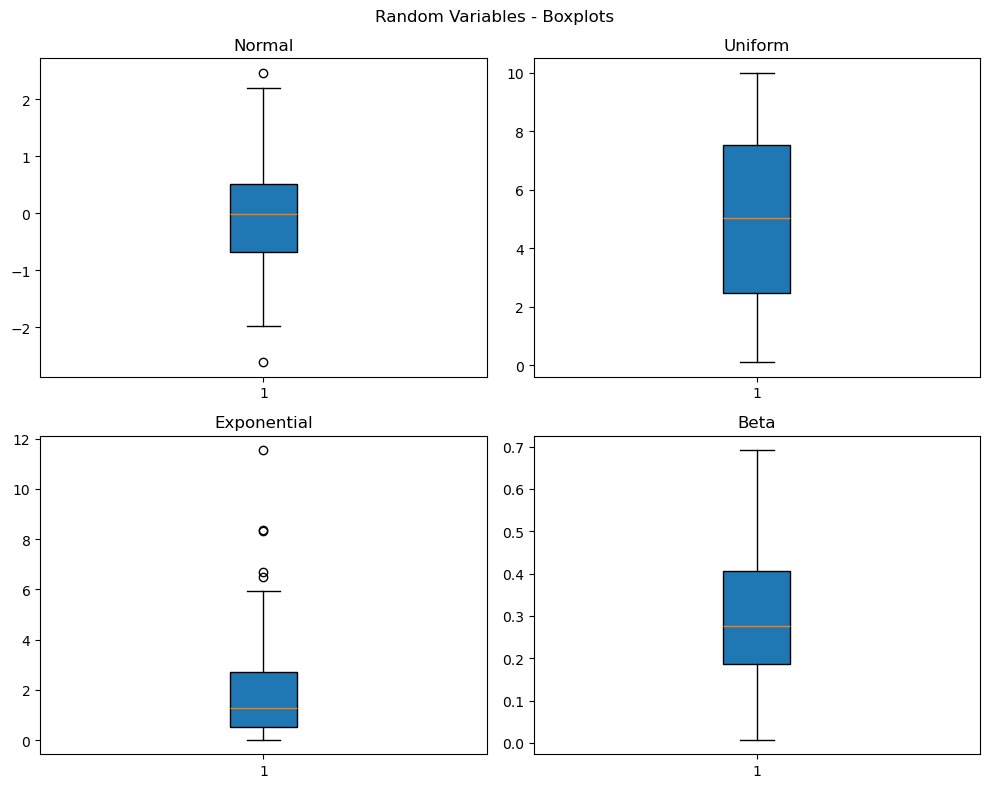

In [41]:
#Problem 3
np.random.seed(42)
 
x1 = np.random.normal(0, 1,random.randint(100, 500))
x2 = np.random.uniform(0, 10,random.randint(100, 500))
x3 = np.random.exponential(2,random.randint(100, 500))
x4 = np.random.beta(2, 5,random.randint(100, 500))
data = [x1, x2, x3, x4]
names = ['Normal', 'Uniform', 'Exponential', 'Beta']
# TASK 2 - 2x2 matrix of boxplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i in range(4):
    axes[i].boxplot(data[i], patch_artist=True)
    axes[i].set_title(names[i])
 
plt.suptitle('Random Variables - Boxplots')
plt.tight_layout()
plt.show()